In [18]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter, center_of_mass

# Load the Raman mapping dataset
csv_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\50ug_1final.csv'  # Replace with your dataset file path
data = pd.read_csv(csv_file_path)

# Ensure the data is in the correct shape for prediction
input_shape = (data.shape[1], 1)  # Adjust if needed for your specific model
X = data.values.reshape(data.shape[0], data.shape[1], 1)  # Reshape for the model

# Assuming `ps_confidence` is already computed from your predictions
# Example:
# ps_confidence = cnn_model.predict(X)[:, 1]

# Step 1: Reshape the confidence values into a grid
grid_rows = int(np.floor(np.sqrt(ps_confidence.size)))
grid_cols = int(np.ceil(ps_confidence.size / grid_rows))
confidence_grid = np.resize(ps_confidence, (grid_rows, grid_cols))

# Step 2: Smooth the confidence grid (optional, for better COM calculation)
smoothed_grid = gaussian_filter(confidence_grid, sigma=2)

# Step 3: Find the location of the maximum confidence
max_idx = np.unravel_index(np.argmax(smoothed_grid), smoothed_grid.shape)
print(f"Location of the brightest region: {max_idx}")

# Step 4: Map the grid location back to the original dataset
flat_index = max_idx[0] * grid_cols + max_idx[1]  # Convert 2D grid index to 1D index
spectrum = data.iloc[flat_index]  # Extract the spectrum from the original data

# Print the extracted spectrum
print("Extracted Spectrum:")
print(spectrum)

# (Optional) Save the extracted spectrum to a CSV file
output_path = r'extracted_spectrum.csv'
spectrum.to_csv(output_path, index=False)
print(f"Spectrum saved to {output_path}")


Location of the brightest region: (39, 41)
Extracted Spectrum:
0.8421052632        0.588235
0.5263157895        0.470588
0.7368421053        0.470588
0.5789473684        0.470588
0.6315789474        0.470588
                      ...   
0.5263157895.131    0.352941
0.5789473684.166    0.764706
0.5263157895.132    0.823529
0.4736842105.107    0.470588
0.5789473684.167    0.588235
Name: 2030, Length: 850, dtype: float64
Spectrum saved to extracted_spectrum.csv


Brightest region location: (16, 13)
Extracted spectrum index: 829
Smoothed spectrum saved to: smoothed_spectrum.csv


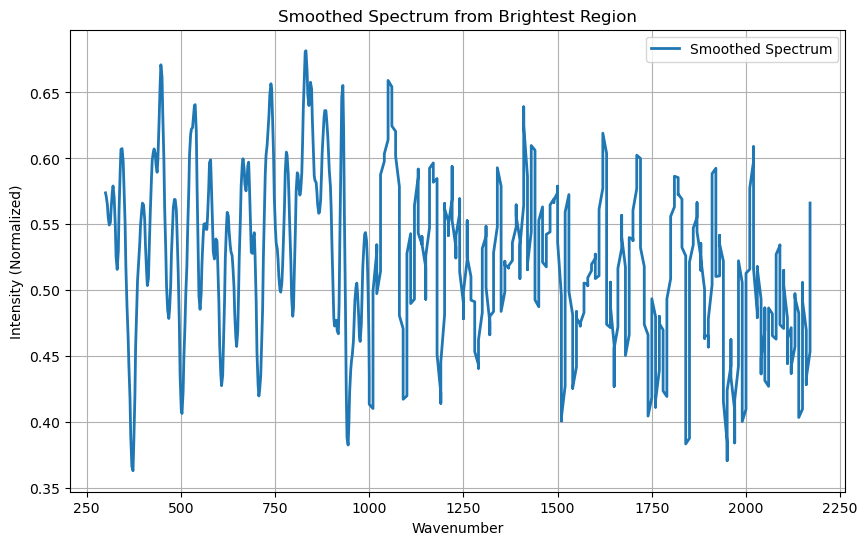

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, gaussian_filter1d, label

# Load the Raman mapping dataset
csv_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\500nmvalidation.csv'  # Replace with your dataset file path
data = pd.read_csv(csv_file_path)

# Ensure all data values are numeric
data = data.apply(pd.to_numeric, errors='coerce').fillna(0)  # Replace non-numeric values with 0

# Load the x-axis values from a separate file
x_axis_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\xaxis.csv'  # Replace with your x-axis file path
x_axis = pd.read_csv(x_axis_file_path, header=None).values.flatten()  # Load and flatten x-axis values
assert len(x_axis) == data.shape[1], "X-axis values do not match the number of columns in the dataset."

# Assuming `ps_confidence` is available from your CNN predictions
# Example: Replace this placeholder with actual confidence values from your model
ps_confidence = np.random.rand(data.shape[0])  # Replace with actual predictions

# Step 1: Reshape confidence values into a grid
grid_rows = int(np.floor(np.sqrt(ps_confidence.size)))
grid_cols = int(np.ceil(ps_confidence.size / grid_rows))
confidence_grid = np.resize(ps_confidence, (grid_rows, grid_cols))

# Step 2: Smooth the confidence grid (optional, for better center detection)
smoothed_grid = gaussian_filter(confidence_grid, sigma=2)

# Step 3: Find the location of the brightest region
max_idx = np.unravel_index(np.argmax(smoothed_grid), smoothed_grid.shape)
print(f"Brightest region location: {max_idx}")

# Step 4: Map the grid location back to the original dataset
flat_index = max_idx[0] * grid_cols + max_idx[1]  # Convert 2D grid index to 1D index
spectrum = data.iloc[flat_index].values  # Extract the spectrum from the original data
print(f"Extracted spectrum index: {flat_index}")

# Step 5: Normalize the spectrum (optional, for better visualization)
spectrum = spectrum / np.max(spectrum) if np.max(spectrum) != 0 else spectrum

# Step 6: Smooth the spectrum using a Gaussian filter
smoothed_spectrum = gaussian_filter1d(spectrum, sigma=2)  # Adjust sigma for smoothing level

# Step 7: Save the smoothed spectrum and x-axis to a CSV file
output_file_path = r'smoothed_spectrum.csv'  # Replace with your desired save path
smoothed_data = pd.DataFrame({
    "x_axis": x_axis,
    "smoothed_spectrum": smoothed_spectrum
})
smoothed_data.to_csv(output_file_path, index=False, float_format="%.6f")  # Save with float precision
print(f"Smoothed spectrum saved to: {output_file_path}")

# Step 8: Plot the original and smoothed spectra
plt.figure(figsize=(10, 6))
#plt.plot(x_axis, spectrum, label="Original Spectrum", alpha=0.6, linestyle="dotted")
plt.plot(x_axis, smoothed_spectrum, label="Smoothed Spectrum", linewidth=2)
plt.title("Smoothed Spectrum from Brightest Region")
plt.xlabel("Wavenumber")  # Adjust the x-axis label as per your data
plt.ylabel("Intensity (Normalized)")
plt.legend()
plt.grid()
plt.show()


1D index for location (7, 9): 114
Extracted spectrum at location (7, 9)


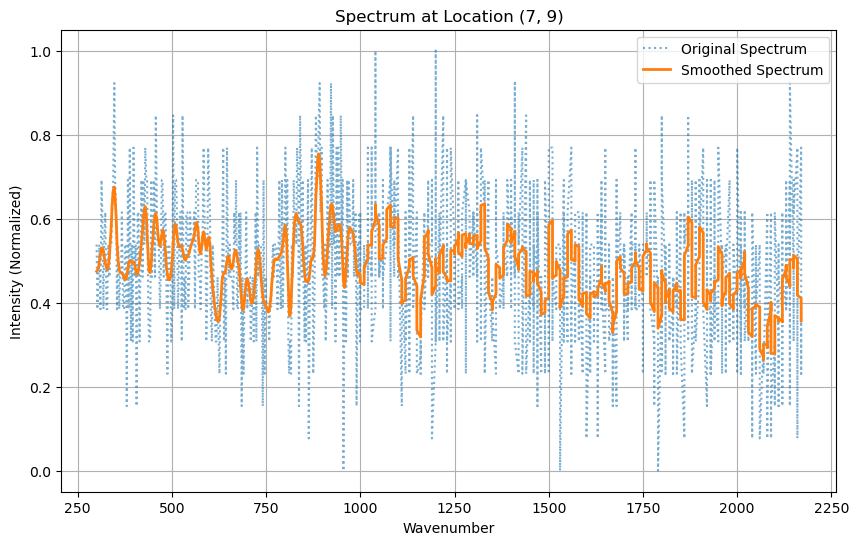

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Load the Raman mapping dataset
csv_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\500nmvalidation.csv'  # Replace with your dataset file path
data = pd.read_csv(csv_file_path)

# Ensure all data values are numeric
data = data.apply(pd.to_numeric, errors='coerce').fillna(0)  # Replace non-numeric values with 0

# Load the x-axis values from a separate file
x_axis_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\xaxis.csv'  # Replace with your x-axis file path
x_axis = pd.read_csv(x_axis_file_path, header=None).values.flatten()  # Load and flatten x-axis values
assert len(x_axis) == data.shape[1], "X-axis values do not match the number of columns in the dataset."

# Assuming the grid size is known
grid_rows = 30  # Adjust based on your grid size
grid_cols = 15  # Adjust based on your grid size

# Step 1: Map the 2D location (20, 9) to the 1D index
row, col = 7, 9
flat_index = row * grid_cols + col
print(f"1D index for location ({row}, {col}): {flat_index}")

# Step 2: Extract the spectrum at the given location
spectrum = data.iloc[flat_index].values
print(f"Extracted spectrum at location ({row}, {col})")

# Step 3: Normalize the spectrum (optional, for better visualization)
spectrum = spectrum / np.max(spectrum) if np.max(spectrum) != 0 else spectrum

# Step 4: Smooth the spectrum using a Gaussian filter
smoothed_spectrum = gaussian_filter1d(spectrum, sigma=2)  # Adjust sigma for smoothing level

# Step 5: Plot the spectrum
plt.figure(figsize=(10, 6))
plt.plot(x_axis, spectrum, label="Original Spectrum", alpha=0.6, linestyle="dotted")
plt.plot(x_axis, smoothed_spectrum, label="Smoothed Spectrum", linewidth=2)
plt.title(f"Spectrum at Location ({row}, {col})")
plt.xlabel("Wavenumber")  # Adjust the x-axis label as per your data
plt.ylabel("Intensity (Normalized)")
plt.legend()
plt.grid()
plt.show()


In [47]:
import numpy as np
import pandas as pd

# Load the Raman mapping dataset
csv_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\predict1.csv'  # Replace with your dataset file path
data = pd.read_csv(csv_file_path)

# Ensure all data values are numeric
data = data.apply(pd.to_numeric, errors='coerce').fillna(0)  # Replace non-numeric values with 0

# Load the x-axis values from a separate file
x_axis_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\xaxis.csv'  # Replace with your x-axis file path
x_axis = pd.read_csv(x_axis_file_path, header=None).values.flatten()  # Load and flatten x-axis values
assert len(x_axis) == data.shape[1], "X-axis values do not match the number of columns in the dataset."

# Step 1: Locate the column corresponding to 1001 wavenumber
target_wavenumber = 1001
wavenumber_idx = np.argmin(np.abs(x_axis - target_wavenumber))
print(f"Column index for wavenumber {target_wavenumber}: {wavenumber_idx}")

# Step 2: Extract intensities at 1001 wavenumber
intensities_at_target = data.iloc[:, wavenumber_idx].values

# Step 3: Find the row with the highest intensity
max_intensity_idx = np.argmax(intensities_at_target)
max_intensity = intensities_at_target[max_intensity_idx]
print(f"Row with highest intensity at {target_wavenumber} wavenumber: {max_intensity_idx}")
print(f"Highest intensity value: {max_intensity}")

# Step 4: Map the 1D index to a 2D grid location
grid_rows = 30  # Adjust based on your grid size
grid_cols = 15  # Adjust based on your grid size
row_2d = max_intensity_idx // grid_cols
col_2d = max_intensity_idx % grid_cols
print(f"Grid location of highest intensity: ({row_2d}, {col_2d})")

# (Optional) Extract the corresponding spectrum
spectrum = data.iloc[max_intensity_idx].values


Column index for wavenumber 1001: 285
Row with highest intensity at 1001 wavenumber: 67
Highest intensity value: 1.0
Grid location of highest intensity: (4, 7)


Column index for wavenumber 1000: 285
Row with highest intensity at 1000 wavenumber: 60
Highest intensity value: 1.0
Grid location of highest intensity: (4, 0)


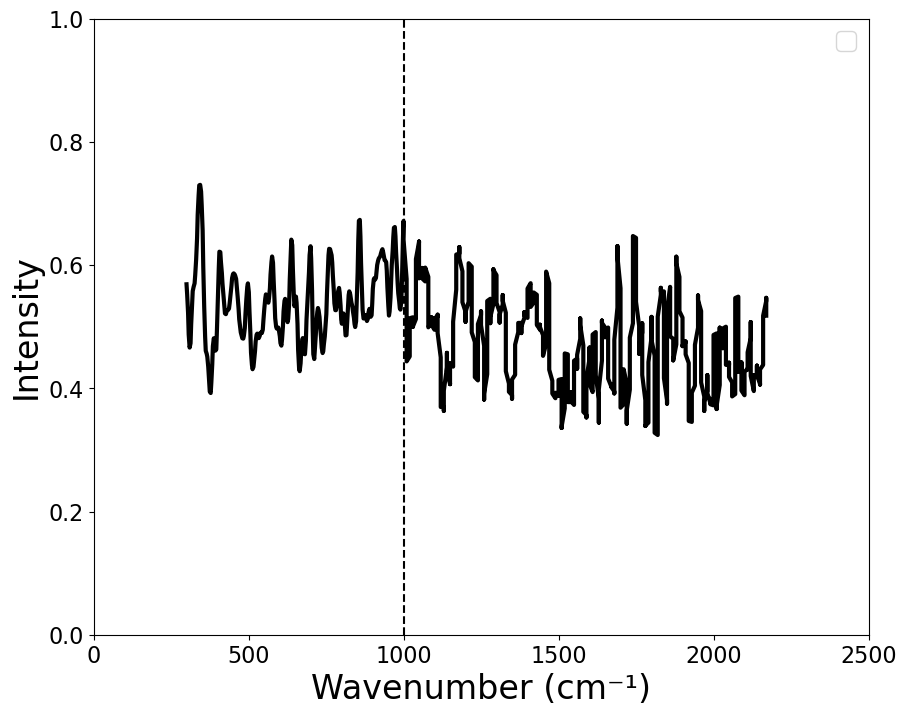

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Load the Raman mapping dataset
csv_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\AG104predict.csv'  # Replace with your dataset file path
data = pd.read_csv(csv_file_path)

# Ensure all data values are numeric
data = data.apply(pd.to_numeric, errors='coerce').fillna(0)  # Replace non-numeric values with 0

# Load the x-axis values from a separate file
x_axis_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\xaxis.csv'  # Replace with your x-axis file path
x_axis = pd.read_csv(x_axis_file_path, header=None).values.flatten()  # Load and flatten x-axis values
assert len(x_axis) == data.shape[1], "X-axis values do not match the number of columns in the dataset."

# Step 1: Locate the column corresponding to 1001 wavenumber
target_wavenumber = 1000
wavenumber_idx = np.argmin(np.abs(x_axis - target_wavenumber))
print(f"Column index for wavenumber {target_wavenumber}: {wavenumber_idx}")

# Step 2: Extract intensities at 1001 wavenumber
intensities_at_target = data.iloc[:, wavenumber_idx].values

# Step 3: Find the row with the highest intensity
max_intensity_idx = np.argmax(intensities_at_target)
max_intensity = intensities_at_target[max_intensity_idx]
print(f"Row with highest intensity at {target_wavenumber} wavenumber: {max_intensity_idx}")
print(f"Highest intensity value: {max_intensity}")

# Step 4: Map the 1D index to a 2D grid location
grid_rows = 30  # Adjust based on your grid size
grid_cols = 15  # Adjust based on your grid size
row_2d = max_intensity_idx // grid_cols
col_2d = max_intensity_idx % grid_cols
print(f"Grid location of highest intensity: ({row_2d}, {col_2d})")

# Step 5: Extract the spectrum at the identified location
spectrum = data.iloc[max_intensity_idx].values

# Step 6: Smooth the spectrum using a Gaussian filter
smoothed_spectrum = gaussian_filter1d(spectrum, sigma=2)  # Adjust sigma for smoothing level

plt.figure(figsize=(10, 8))
plt.plot(x_axis, smoothed_spectrum,  linewidth=3, color="black")
plt.axvline(x=1001, color="black", linestyle="--", linewidth=1.5)  # Add dashed line at 1001
#plt.title(f"Smoothed Spectrum with Highest Intensity at {target_wavenumber} Wavenumber", fontsize=18)
plt.xlabel("Wavenumber (cm⁻¹)", fontsize=24)  # Set font size for x-axis label
plt.ylabel("Intensity", fontsize=24)  # Set font size for y-axis label
plt.legend(fontsize=18)  # Set font size for legend
plt.xlim(0, 2500)  # Set x-axis range
plt.ylim(0, 1)  # Set y-axis rang
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
Number of PS detected (confidence > 0.6): 516


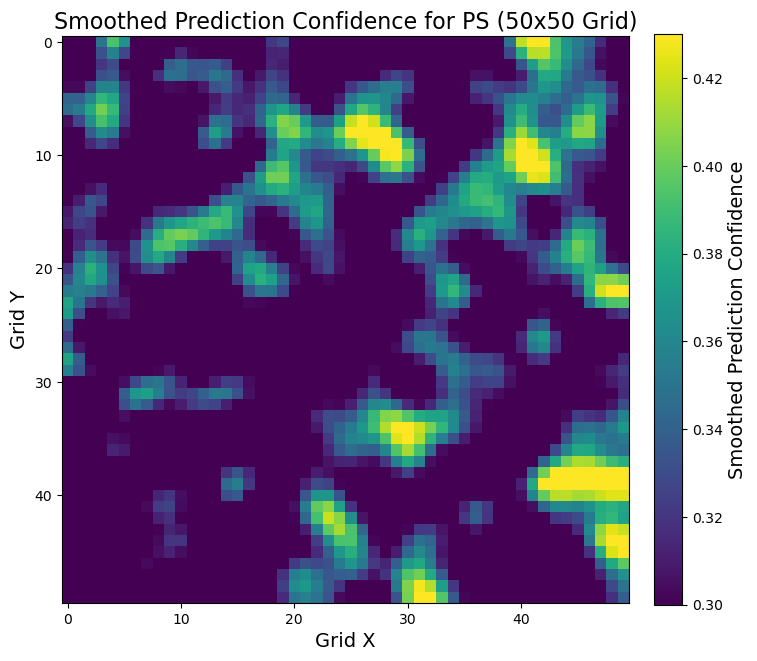

Smoothed grid image saved to: C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\map3final.png


<Figure size 640x480 with 0 Axes>

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from scipy.ndimage import gaussian_filter

# Load the trained CNN model
model_path = "fine_tuned_model.h5"  # Replace with your model file path
cnn_model = load_model(model_path)

# Load the Raman mapping dataset
csv_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\AG104predict.csv'  # Replace with your dataset file path
data = pd.read_csv(csv_file_path)

# Ensure the data is in the correct shape for prediction
input_shape = (data.shape[1], 1)  # Adjust if needed for your specific model
X = data.values.reshape(data.shape[0], data.shape[1], 1)  # Reshape for the model

# Make predictions
predictions = cnn_model.predict(X)

# Extract confidence for class 1 (PS present)
ps_confidence = predictions[:, 1]  # Class 1 corresponds to PS

# Count the number of PS detected based on a threshold
threshold = 0.6
num_ps_detected = np.sum(ps_confidence > threshold)
print(f"Number of PS detected (confidence > {threshold}): {num_ps_detected}")

# Step 1: Map the confidence levels into a fixed 50x50 grid
if len(ps_confidence) != 2500:
    raise ValueError(f"Expected 2500 predictions, but got {len(ps_confidence)}")

grid_rows, grid_cols = 50, 50  # Define fixed grid dimensions
confidence_grid = ps_confidence.reshape((grid_rows, grid_cols))  # Reshape into 50x50 grid

# Step 2: Smooth the grid using Gaussian filter
sigma = 1.5  # Adjust this value to control the smoothing level
smoothed_grid = gaussian_filter(confidence_grid, sigma=sigma)

# Step 3: Plot the smoothed grid with adjusted confidence levels
fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.get_cmap("viridis")
img = ax.imshow(smoothed_grid, cmap=cmap, origin="upper", vmin=0.3, vmax=0.43)  # Adjust color scale

# Adjust layout to place colorbar
cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Smoothed Prediction Confidence", fontsize=14)

plt.title("Smoothed Prediction Confidence for PS (50x50 Grid)", fontsize=16)
plt.xlabel("Grid X", fontsize=14)
plt.ylabel("Grid Y", fontsize=14)
plt.show()


# Step 4: Save the image to a PNG file
output_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\map3final.png'  # Replace with your desired file path
plt.savefig(output_file_path, dpi=300, bbox_inches='tight')  # Save the figure with high resolution
print(f"Smoothed grid image saved to: {output_file_path}")

In [29]:
from skimage.metrics import structural_similarity as ssim
import numpy as np
from PIL import Image

# Paths to your image files
image1_path = r'C:\Users\Liyuan\Desktop\TCA1s.png'  # Replace with the path to your first image
image2_path = r'C:\Users\Liyuan\Desktop\TCA0.1s.png'  # Replace with the path to your second image

# Convert images to grayscale and numpy arrays
image1 = np.array(Image.open(image1_path).convert("L"))
image2 = np.array(Image.open(image2_path).convert("L"))

# Calculate Structural Similarity Index (SSIM)
ssim_index, _ = ssim(image1, image2, full=True)

# Calculate Mean Squared Error (MSE)
mse = np.mean((image1 - image2) ** 2)

# Calculate Pearson Correlation Coefficient
correlation = np.corrcoef(image1.flatten(), image2.flatten())[0, 1]

print(f"SSIM: {ssim_index}")
print(f"MSE: {mse}")
print(f"Pearson Correlation: {correlation}")


SSIM: 0.2962170923632831
MSE: 96.09271418578939
Pearson Correlation: 0.9815040144964028


79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Number of PS detected (confidence > 0.6): 1163
Smoothed grid image saved to: C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\map4final.png


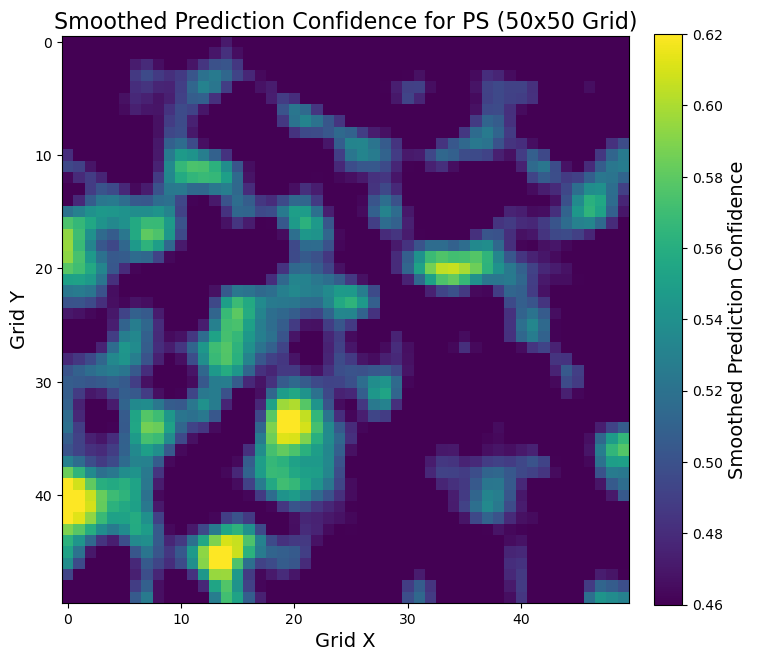

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from scipy.ndimage import gaussian_filter

# Load the trained CNN model
model_path = "fine_tuned_model.h5"  # Replace with your model file path
cnn_model = load_model(model_path)

# Load the Raman mapping dataset
csv_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\Maparea2predict.csv'  # Replace with your dataset file path
data = pd.read_csv(csv_file_path)

# Ensure the data is in the correct shape for prediction
input_shape = (data.shape[1], 1)  # Adjust if needed for your specific model
X = data.values.reshape(data.shape[0], data.shape[1], 1)  # Reshape for the model

# Make predictions
predictions = cnn_model.predict(X)

# Extract confidence for class 1 (PS present)
ps_confidence = predictions[:, 1]  # Class 1 corresponds to PS

# Count the number of PS detected based on a threshold
threshold = 0.6
num_ps_detected = np.sum(ps_confidence > threshold)
print(f"Number of PS detected (confidence > {threshold}): {num_ps_detected}")

# Step 1: Map the confidence levels into a fixed 50x50 grid
if len(ps_confidence) != 2500:
    raise ValueError(f"Expected 2500 predictions, but got {len(ps_confidence)}")

grid_rows, grid_cols = 50, 50  # Define fixed grid dimensions
confidence_grid = ps_confidence.reshape((grid_rows, grid_cols))  # Reshape into 50x50 grid

# Step 2: Smooth the grid using Gaussian filter
sigma = 1.5  # Adjust this value to control the smoothing level
smoothed_grid = gaussian_filter(confidence_grid, sigma=sigma)

# Step 3: Plot the smoothed grid with adjusted confidence levels
fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.get_cmap("viridis")
img = ax.imshow(smoothed_grid, cmap=cmap, origin="upper", vmin=0.46, vmax=0.62)  # Adjust color scale

# Adjust layout to place colorbar
cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Smoothed Prediction Confidence", fontsize=14)

plt.title("Smoothed Prediction Confidence for PS (50x50 Grid)", fontsize=16)
plt.xlabel("Grid X", fontsize=14)
plt.ylabel("Grid Y", fontsize=14)

# Step 4: Save the image to a PNG file
output_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\map4final.png'  # Replace with your desired file path
plt.savefig(output_file_path, dpi=300, bbox_inches='tight')  # Save the figure with high resolution
print(f"Smoothed grid image saved to: {output_file_path}")

plt.show()


79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


Number of PS detected (confidence > 0.75): 3
Location with highest confidence: (16, 47)
Highest confidence level: 0.9711369276046753


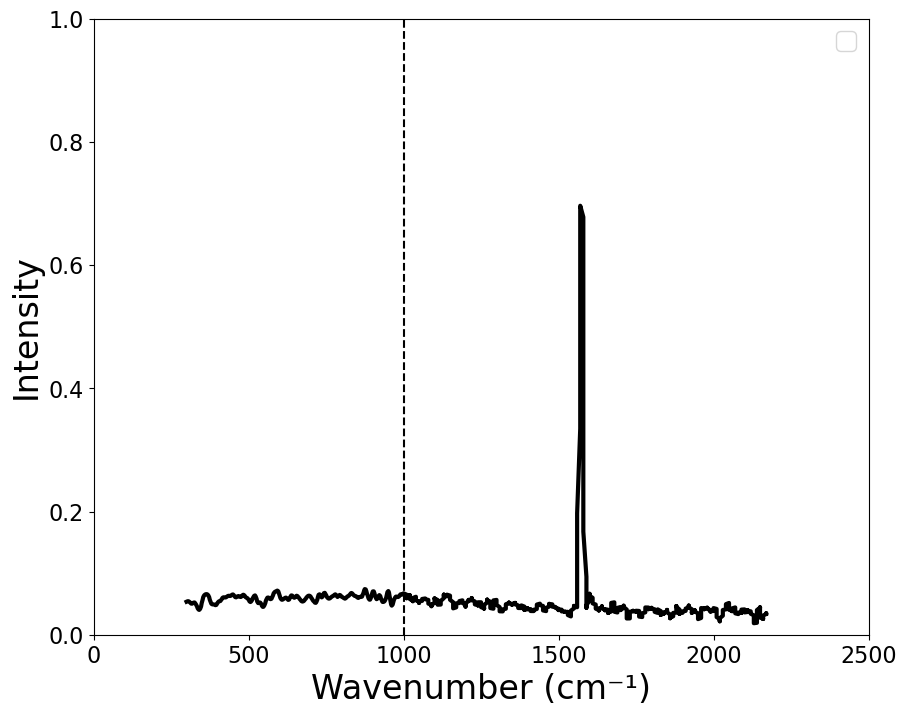

Spectrum saved to: C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\map1final_openspecy.csv


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from scipy.ndimage import gaussian_filter, gaussian_filter1d

# Load the trained CNN model
model_path = "fine_tuned_model.h5"  # Replace with your model file path
cnn_model = load_model(model_path)

# Load the Raman mapping dataset
csv_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\AG208predict.csv'  # Replace with your dataset file path
data = pd.read_csv(csv_file_path)

# Ensure the data is in the correct shape for prediction
input_shape = (data.shape[1], 1)  # Adjust if needed for your specific model
X = data.values.reshape(data.shape[0], data.shape[1], 1)  # Reshape for the model

# Make predictions
predictions = cnn_model.predict(X)

# Extract confidence for class 1 (PS present)
ps_confidence = predictions[:, 1]  # Class 1 corresponds to PS

# Count the number of PS detected based on a threshold
threshold = 0.75
num_ps_detected = np.sum(ps_confidence > threshold)
print(f"Number of PS detected (confidence > {threshold}): {num_ps_detected}")

# Step 1: Map the confidence levels into a fixed 50x50 grid
if len(ps_confidence) != 2500:
    raise ValueError(f"Expected 2500 predictions, but got {len(ps_confidence)}")

grid_rows, grid_cols = 50, 50  # Define fixed grid dimensions
confidence_grid = ps_confidence.reshape((grid_rows, grid_cols))  # Reshape into 50x50 grid

# Step 2: Find the location with the highest confidence level
highest_confidence_index = np.argmax(ps_confidence)
row, col = divmod(highest_confidence_index, grid_cols)
print(f"Location with highest confidence: ({row}, {col})")
print(f"Highest confidence level: {ps_confidence[highest_confidence_index]}")

# Step 3: Extract the spectrum corresponding to the highest confidence
spectrum = data.iloc[highest_confidence_index].values  # Extract spectrum at the highest confidence location

# Load the x-axis values for the spectrum
x_axis_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\xaxis.csv'  # Replace with your x-axis file path
x_axis = pd.read_csv(x_axis_file_path, header=None).values.flatten()
assert len(x_axis) == len(spectrum), "X-axis values do not match the spectrum length."

# Step 4: Smooth the spectrum using a Gaussian filter
smoothed_spectrum = gaussian_filter1d(spectrum, sigma=2)

# Step 5: Plot the spectrum

plt.figure(figsize=(10, 8))
plt.plot(x_axis, smoothed_spectrum,  linewidth=3, color="black")
plt.axvline(x=1001, color="black", linestyle="--", linewidth=1.5)  # Add dashed line at 1001
#plt.title(f"Smoothed Spectrum with Highest Intensity at {target_wavenumber} Wavenumber", fontsize=18)
plt.xlabel("Wavenumber (cm⁻¹)", fontsize=24)  # Set font size for x-axis label
plt.ylabel("Intensity", fontsize=24)  # Set font size for y-axis label
plt.legend(fontsize=18)  # Set font size for legend
plt.xlim(0, 2500)  # Set x-axis range
plt.ylim(0, 1)  # Set y-axis rang
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

spectrum_output_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\map1final_openspecy.csv'  # Replace with your desired file path
spectrum_df = pd.DataFrame({"Wavenumber (cm⁻¹)": x_axis, "Original Intensity": spectrum, "Smoothed Intensity": smoothed_spectrum})
spectrum_df.to_csv(spectrum_output_path, index=False)
print(f"Spectrum saved to: {spectrum_output_path}")

In [16]:
# how about compare to the brightfield? 


import numpy as np
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from scipy.stats import pearsonr

# Load the two images
brightfield_image_path = r'C:\Users\Liyuan\Desktop\CNN1.png'  # Replace with your image path
tca_cnn_image_path = r'C:\Users\Liyuan\Desktop\TCA1.png'  # Replace with your image path

# Open the images and convert them to grayscale
brightfield_image = Image.open(brightfield_image_path).convert("L")  # Convert to grayscale
tca_cnn_image = Image.open(tca_cnn_image_path).convert("L")  # Convert to grayscale

# Resize both images to the same dimensions
target_size = (512, 512)  # Adjust to the desired size
brightfield_resized = brightfield_image.resize(target_size, Image.Resampling.LANCZOS)
tca_cnn_resized = tca_cnn_image.resize(target_size, Image.Resampling.LANCZOS)

# Convert images to numpy arrays
brightfield_array = np.array(brightfield_resized)
tca_cnn_array = np.array(tca_cnn_resized)

# Normalize arrays (optional, for intensity comparison)
brightfield_array = brightfield_array / 255.0
tca_cnn_array = tca_cnn_array / 255.0

# Calculate Structural Similarity Index (SSIM)
ssim_index, _ = ssim(brightfield_array, tca_cnn_array, data_range=1.0, full=True)

# Calculate Mean Squared Error (MSE)
mse = np.mean((brightfield_array - tca_cnn_array) ** 2)

# Calculate Pearson Correlation Coefficient
pearson_corr, _ = pearsonr(brightfield_array.flatten(), tca_cnn_array.flatten())

# Print the comparison metrics
print(f"SSIM: {ssim_index}")
print(f"MSE: {mse}")
print(f"Pearson Correlation: {pearson_corr}")

# Optional: Save resized images for visual comparison
brightfield_resized.save(r"path_to_save_resized_brightfield.png")
tca_cnn_resized.save(r"path_to_save_resized_tca_cnn.png")


SSIM: 0.08641251291106712
MSE: 0.2667253132739098
Pearson Correlation: 0.8335350110442661


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step


Number of PS detected (confidence in range 0.68 to 0.71): 268
Location with highest confidence: (32, 15)
Highest confidence level: 0.9620785117149353


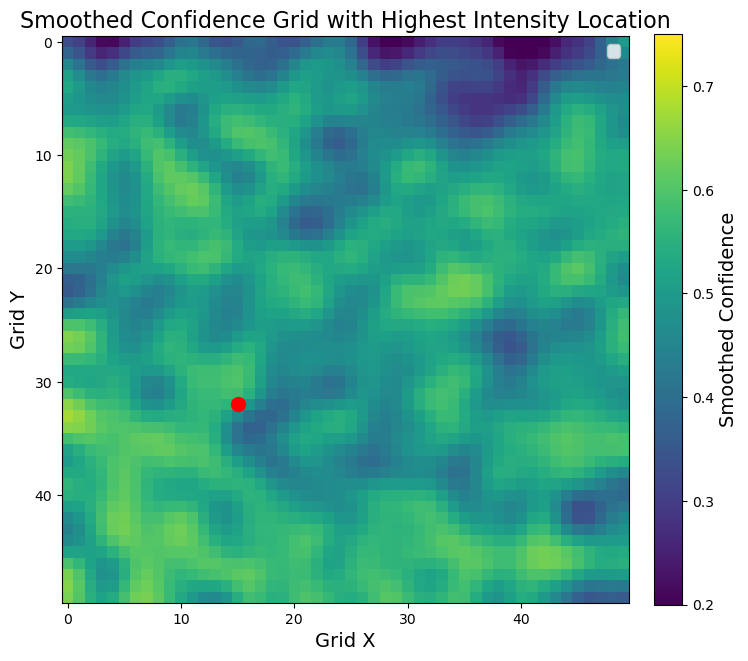

Smoothed grid image saved to: C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\smoothed_grid_map2final.png


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from scipy.ndimage import gaussian_filter, gaussian_filter1d

# Load the trained CNN model
model_path = "fine_tuned_model.h5"  # Replace with your model file path
cnn_model = load_model(model_path)

# Load the Raman mapping dataset
csv_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\D33predict.csv'  # Replace with your dataset file path
data = pd.read_csv(csv_file_path)

# Ensure the data is in the correct shape for prediction
input_shape = (data.shape[1], 1)  # Adjust if needed for your specific model
X = data.values.reshape(data.shape[0], data.shape[1], 1)  # Reshape for the model

# Make predictions
predictions = cnn_model.predict(X)

# Extract confidence for class 1 (PS present)
ps_confidence = predictions[:, 1]  # Class 1 corresponds to PS

# Count the number of PS detected based on a confidence range
lower_threshold = 0.68
upper_threshold = 0.71
num_ps_detected = np.sum((ps_confidence >= lower_threshold) & (ps_confidence <= upper_threshold))
print(f"Number of PS detected (confidence in range {lower_threshold} to {upper_threshold}): {num_ps_detected}")

# Step 1: Map the confidence levels into a fixed 50x50 grid
if len(ps_confidence) != 2500:
    raise ValueError(f"Expected 2500 predictions, but got {len(ps_confidence)}")

grid_rows, grid_cols = 50, 50  # Define fixed grid dimensions
confidence_grid = ps_confidence.reshape((grid_rows, grid_cols))  # Reshape into 50x50 grid

# Step 2: Smooth the confidence grid using a Gaussian filter
sigma = 1.5  # Adjust the sigma value for smoothing
smoothed_grid = gaussian_filter(confidence_grid, sigma=sigma)

# Step 3: Find the location with the highest confidence level
highest_confidence_index = np.argmax(ps_confidence)
row, col = divmod(highest_confidence_index, grid_cols)
print(f"Location with highest confidence: ({row}, {col})")
print(f"Highest confidence level: {ps_confidence[highest_confidence_index]}")

# Step 4: Plot the smoothed confidence grid with the highest intensity location marked
fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.get_cmap("viridis")
img = ax.imshow(smoothed_grid, cmap=cmap, origin="upper", vmin=0.2, vmax=0.75)  # Adjust color scale
ax.scatter(col, row, color='red', s=100)  # Mark the highest intensity location
cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Smoothed Confidence", fontsize=14)
plt.title("Smoothed Confidence Grid with Highest Intensity Location", fontsize=16)
plt.xlabel("Grid X", fontsize=14)
plt.ylabel("Grid Y", fontsize=14)
plt.legend(fontsize=12)
plt.show()

# Step 5: Save the smoothed grid image
output_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\smoothed_grid_map2final.png'
fig.savefig(output_file_path, dpi=300, bbox_inches='tight')
print(f"Smoothed grid image saved to: {output_file_path}")




79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
Number of points with confidence > 0.65: 787


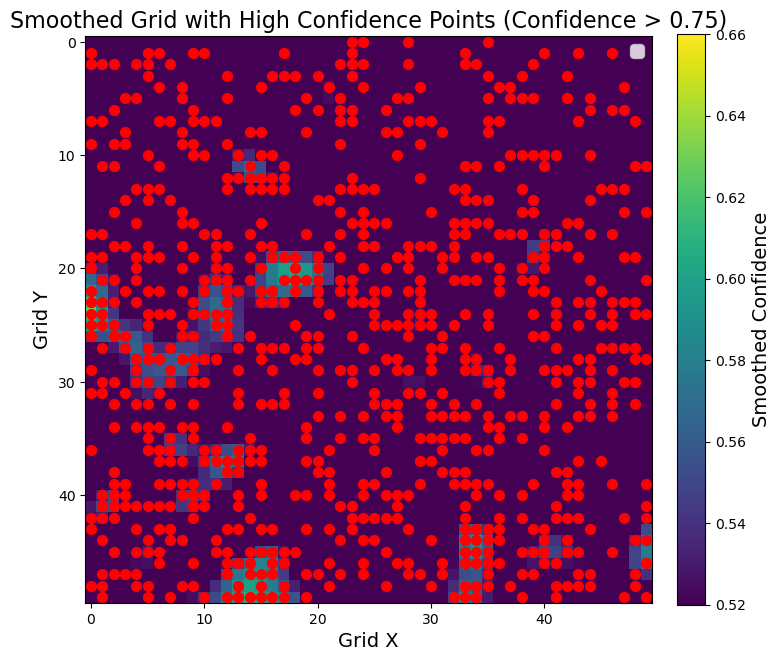

Randomly selected high-confidence point: (18, 30)


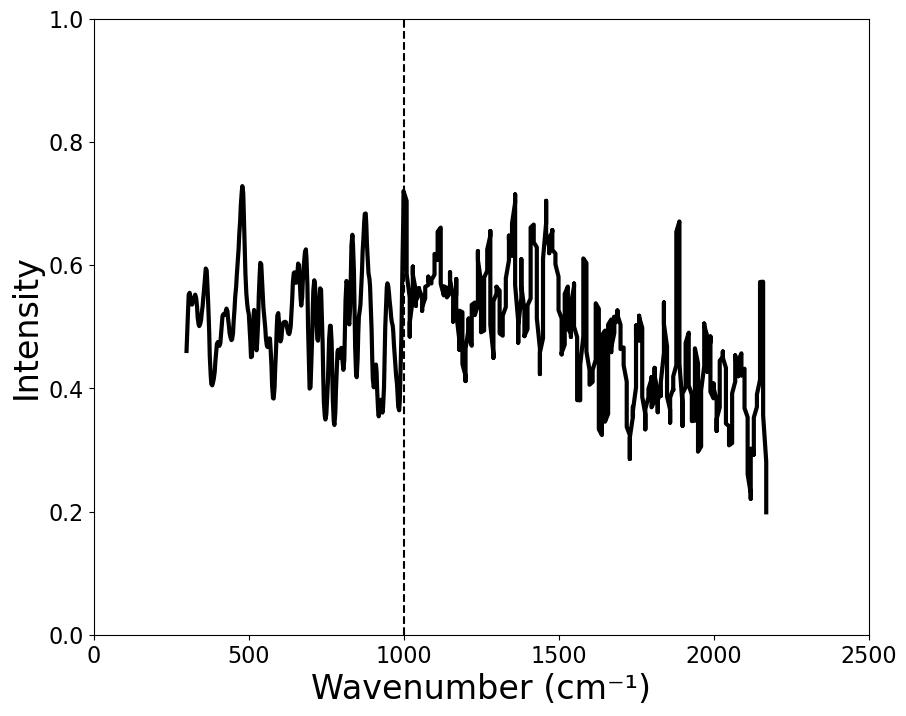

Randomly selected high-confidence point: (20, 12)
Random spectrum saved to: C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\25ugarea1final.csv


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from scipy.ndimage import gaussian_filter, gaussian_filter1d
import random

# Load the Raman mapping dataset
csv_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\DIarea1predict.csv'  # Replace with your dataset file path
data = pd.read_csv(csv_file_path)

# Ensure all data values are numeric
data = data.apply(pd.to_numeric, errors='coerce').fillna(0)  # Replace non-numeric values with 0

# Load the x-axis values from a separate file
x_axis_file_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\xaxis.csv'  # Replace with your x-axis file path
x_axis = pd.read_csv(x_axis_file_path, header=None).values.flatten()  # Load and flatten x-axis values
assert len(x_axis) == data.shape[1], "X-axis values do not match the number of columns in the dataset."

# Load the trained CNN model and make predictions
model_path = "fine_tuned_model.h5"  # Replace with your model file path
cnn_model = load_model(model_path)
X = data.values.reshape(data.shape[0], data.shape[1], 1)  # Reshape for the model
predictions = cnn_model.predict(X)
ps_confidence = predictions[:, 1]  # Class 1 corresponds to PS

# Step 1: Identify locations with confidence > 0.75
confidence_threshold = 0.65
high_confidence_indices = np.where(ps_confidence > confidence_threshold)[0]
print(f"Number of points with confidence > {confidence_threshold}: {len(high_confidence_indices)}")

# Step 2: Map confidence values to a grid and smooth the grid
grid_rows, grid_cols = 50, 50  # Adjust based on your grid size
confidence_grid = ps_confidence.reshape((grid_rows, grid_cols))  # Reshape to grid
smoothed_grid = gaussian_filter(confidence_grid, sigma=1.5)  # Smooth the grid

# Step 3: Highlight all high-confidence points on the smoothed grid
fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.get_cmap("viridis")
img = ax.imshow(smoothed_grid, cmap=cmap, origin="upper", vmin=0.52, vmax=0.66)  # Adjust color scale
for idx in high_confidence_indices:
    row, col = divmod(idx, grid_cols)
    ax.scatter(col, row, color='red', s=50)

# Add colorbar and labels
cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Smoothed Confidence", fontsize=14)
plt.title("Smoothed Grid with High Confidence Points (Confidence > 0.75)", fontsize=16)
plt.xlabel("Grid X", fontsize=14)
plt.ylabel("Grid Y", fontsize=14)
plt.legend(fontsize=12)
plt.show()

# Step 4: Randomly select one high-confidence point and plot its spectrum
random_idx = random.choice(high_confidence_indices)
random_row, random_col = divmod(random_idx, grid_cols)
print(f"Randomly selected high-confidence point: ({random_row}, {random_col})")

# Extract the spectrum at the selected point
random_spectrum = data.iloc[random_idx].values
smoothed_spectrum = gaussian_filter1d(random_spectrum, sigma=2)  # Smooth the spectrum

# Plot the spectrum
plt.figure(figsize=(10, 8))
plt.plot(x_axis, smoothed_spectrum, linewidth=3, color="black")
plt.axvline(x=1000, color="black", linestyle="--", linewidth=1.5)  # Add dashed line at 1000
plt.xlabel("Wavenumber (cm⁻¹)", fontsize=24)
plt.ylabel("Intensity", fontsize=24)
plt.xlim(0, 2500)  # Set x-axis range
plt.ylim(0, 1)  # Set y-axis range
plt.tick_params(axis='both', which='major', labelsize=16)
#plt.title(f"Spectrum at Random High Confidence Location ({random_row}, {random_col})", fontsize=18)
plt.show()

# Step 4: Randomly select one high-confidence point and plot its spectrum
random_idx = random.choice(high_confidence_indices)
random_row, random_col = divmod(random_idx, grid_cols)
print(f"Randomly selected high-confidence point: ({random_row}, {random_col})")

# Extract the spectrum at the selected point
random_spectrum = data.iloc[random_idx].values
smoothed_spectrum = gaussian_filter1d(random_spectrum, sigma=2)  # Smooth the spectrum

# Step 5: Save the random spectrum to a CSV file
output_csv_path = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetunepredict\25ugarea1final.csv'
spectrum_df = pd.DataFrame({"Wavenumber (cm⁻¹)": x_axis, "Intensity": random_spectrum, "Smoothed Intensity": smoothed_spectrum})
spectrum_df.to_csv(output_csv_path, index=False)
print(f"Random spectrum saved to: {output_csv_path}")